## Trying to make sense of the data

## Read this first: a guide for newcomers

This notebook takes one path through a dataset of 720 training runs. It starts with small questions about the runs table and builds up one step at a time. Each cell uses what the cell before it found. By the end it compares runs with and without weight decay. It tries to predict the grokking time from the kernel measured early in training, and then whether a run groks at all.

### Grokking

Grokking is a delay in learning. A network first fits its training data perfectly but still fails on new data. Then, often thousands of steps later, it starts to get the new data right as well. The project asks what sets the length of that delay.

### Map of this notebook

| Part | Question | Runs it uses |
| --- | --- | --- |
| Part 1 | What is in the runs table? | All 720 runs. |
| Part 2 | How does weight decay change the outcome and the grokking time? | All 720 runs, grouped by weight decay. Part 2 ends by choosing two groups. |
| Part 3 | Where does each group grok, and how fast? | The grokked runs with weight decay 3e-5 and without weight decay, side by side. |
| Part 4 | How does the kernel move during one run of each group? | One run from each group, side by side. |
| Part 5 | Does the kernel at step 2,000 go with the grokking time? | Both groups, side by side. |
| Part 6 | What does a straight line fitted to each group say? | Both groups, each in its own section, then side by side. |
| Part 7 | Can the line predict runs it has not seen? | Only the runs with weight decay 3e-5. |
| Part 8 | Can the kernel tell whether a run will grok at all? | All 90 runs of each group, side by side, including the runs that did not grok. |

Three rules keep the two groups apart.

- A variable whose name ends in `_wd` holds only runs with weight decay 3e-5. A variable whose name ends in `_no_wd` holds only runs without weight decay.
- In every figure that shows both groups, the runs with weight decay 3e-5 are on the left in blue, and the runs without weight decay are on the right in orange.
- Every figure title and every part heading names the runs it uses.

### The task and the network

- The task is addition modulo 23. The input is a pair of numbers `a` and `b`, each from 0 to 22, and the answer is `(a + b) mod 23`.
- There are 23 × 23 = 529 possible pairs. 476 of them are the training set and the other 53 are the test set.
- The network has one hidden layer. It gives 23 outputs, one per possible answer, and its guess is the largest output.
- One update of the weights is one **step**. Every run trains for 200,000 steps, which is the **budget**.
- The features are recorded at 307 moments in each run, called **checkpoints**.

### Grokked, censored and never memorised

- A run has **memorised** when its training accuracy reaches 1. The step at which that first happens is `t_mem`.
- A run has **grokked** when, after memorising, its test accuracy also reaches 1. That step is `t_gen_acc100`. The grokking time is the gap between the two, `t_grok_acc100 = t_gen_acc100 - t_mem`.
- A run is **censored** when it memorised but its test accuracy had not reached 1 by step 200,000. We only know that its grokking time is longer than what we watched.
- A run has **never memorised** when its training accuracy never reached 1. It has no grokking time.

Parts 3 to 7 keep only the runs that grokked, because their grokking time is known exactly. Leaving out the censored runs removes the slowest runs, so those results describe runs that grok within the budget. Part 2 shows how many runs this leaves out at each weight decay. Part 8 brings the other runs back and asks which runs grok at all.

### The settings of a run and its name

| Setting | Values | What it means |
| --- | --- | --- |
| `alpha` | 0.5, 1, 2 | The laziness knob. A larger `alpha` lets the network fit the data with smaller changes to its weights, so it stays closer to where it started. |
| `width` | 50 to 1600 | The number of hidden units. |
| `eta_kappa` | 0 to 0.003 | The weight decay. Every step shrinks every weight by a factor of `1 - eta_kappa`. |
| `seed` | 0 to 4 | The random seed for the starting weights. |

Each run has a name built from its settings. `ntk_N200_a1_wd3e-05_s0` means the `ntk` parameterisation (the same in every run), width 200, `alpha` = 1, weight decay `eta_kappa` = 3e-05, and seed 0.

### The kernel and its three numbers

The **kernel** is a table with one row and one column per input pair. The entry for inputs i and j says how much one small training step on input j moves the network's output on input i. A large entry means the network treats the two inputs as similar. The kernel is measured on a fixed set of 256 input pairs called the probe, and it is centred first, which removes the row and column averages.

| Name in the report | Column in the data | Plain meaning |
| --- | --- | --- |
| `A_t` | `A_t` | **Alignment.** How well the shape of the kernel matches the labels, as a cosine. Higher means the network treats inputs with the same answer as more similar. |
| `S_t` | `S_c` | **Scale.** How much the size of the kernel has changed since step 0, on a log scale. 0 means the same size, and 0.7 means about twice as large. |
| `R_t` | `R_c` | **Rotation.** How much the shape of the kernel has turned since step 0. 0 means the same shape. |

The report defines `S_t` and `R_t` on the centred kernel, and in the data those are the columns `S_c` and `R_c`. The data also has columns named `S_t` and `R_t`, but they measure the kernel before centring, which the report does not use. So this notebook reads `S_c` and `R_c` and labels them as the report's `S_t` and `R_t`.

### The two data files

- `data/runs.parquet` has one row per run: its settings, its outcome and its grokking time.
- `data/checkpoints.parquet` has one row per run and checkpoint, with every feature over time. It is large, so we read only the rows and columns we need.

## Setup

This cell loads the libraries and gives every figure the same look. statsmodels fits the straight lines in Parts 6 and 7 and prints their summary tables. scikit-learn fits the two penalised models in Part 7 and the logistic regressions in Part 8, and it scores the models on held-out runs.

Blue always marks runs with weight decay 3e-5, and orange always marks runs without weight decay. Grey marks the other weight decay levels and the reference lines. Violet, aqua and yellow mark the three inputs `A_t`, `S_t` and `R_t` in the penalty plot of Part 7.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, LogisticRegression, Ridge, RidgeCV
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, r2_score
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Blue marks runs with weight decay 3e-5, and orange marks runs without weight decay.
WD_COLOUR = '#2a78d6'
NO_WD_COLOUR = '#eb6834'
# Grey marks the other weight decay levels and the reference lines.
GREY = '#8a8984'
INK = '#0b0b0b'
SURFACE = '#fcfcfb'
# Violet, aqua and yellow mark the three inputs in the penalty plot.
INPUT_COLOURS = {'A_t': '#4a3aa7', 'S_t': '#1baf7a', 'R_t': '#eda100'}

plt.rcParams.update({
    'figure.figsize': (7, 4),
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': '#b5b4ae',
    'axes.grid': True,
    'grid.color': '#e6e5e0',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
    'lines.linewidth': 2,
    'legend.frameon': False,
})

## Part 1. A first look at the runs table

**Runs in this part.** All 720 runs.

We start small. We open the runs table and look at its size. It has one row per run.

In [2]:
runs = pd.read_parquet('data/runs.parquet')
runs.shape

(720, 91)

The table has 720 rows, one per run, and 91 columns. Most columns hold other definitions of the grokking time, or the features at special moments of a run. We need only the four settings and the columns that time the grokking, so we look at those.

In [3]:
settings = ['alpha', 'width', 'eta_kappa', 'seed']
timing = ['memorised', 'censored_acc100', 't_mem', 't_gen_acc100', 't_grok_acc100']
runs[['run_id'] + settings + timing].head()

,run_id,alpha,width,eta_kappa,seed,memorised,censored_acc100,t_mem,t_gen_acc100,t_grok_acc100
0,ntk_N50_a0.5_wd0_s0,0.5,50,0.0,0,True,False,3662.0,7508.0,3846.0
1,ntk_N50_a0.5_wd0_s1,0.5,50,0.0,1,True,False,4981.0,12000.0,7019.0
2,ntk_N50_a0.5_wd0_s2,0.5,50,0.0,2,True,False,4000.0,11000.0,7000.0
3,ntk_N50_a0.5_wd0_s3,0.5,50,0.0,3,True,False,4000.0,11317.0,7317.0
4,ntk_N50_a0.5_wd0_s4,0.5,50,0.0,4,True,False,3305.0,8000.0,4695.0


Each row is one run. `memorised` and `censored_acc100` are True or False, and the three `t_` columns count steps. These five runs all grokked, so their grokking time is exact. For a censored run, `t_grok_acc100` holds 200,000 minus `t_mem`, which is only a lower bound. For a run that never memorised, the `t_` columns are empty.

Next we list the values that each setting takes.

In [4]:
{col: sorted(runs[col].unique().tolist()) for col in settings}

{'alpha': [0.5, 1.0, 2.0],
 'width': [50, 100, 200, 400, 800, 1600],
 'eta_kappa': [0.0, 3e-06, 1e-05, 3e-05, 0.0001, 0.0003, 0.001, 0.003],
 'seed': [0, 1, 2, 3, 4]}

There are 3 values of `alpha`, 6 widths, 8 weight decay levels and 5 seeds. 3 × 6 × 8 × 5 = 720, so the sweep ran every mix of the settings once. Each weight decay level therefore has 3 × 6 × 5 = 90 runs.

## Part 2. How weight decay changes the outcome

**Runs in this part.** All 720 runs, grouped by weight decay.

The guide names three outcomes. We give each run its outcome in a new column, `outcome`. A run that never memorised gets `never memorised`. A run that memorised but did not reach a test accuracy of 1 gets `censored`. Every other run grokked.

In [5]:
runs['outcome'] = np.select(
    [~runs['memorised'], runs['censored_acc100']],
    ['never memorised', 'censored'],
    default='grokked',
)
runs['outcome'].value_counts()

outcome
grokked            336
never memorised    195
censored           189
Name: count, dtype: int64

336 runs grokked, 189 were censored and 195 never memorised. Fewer than half of the runs grokked. Next we count the outcomes at each weight decay level, the column `eta_kappa`.

In [6]:
outcomes = ['grokked', 'censored', 'never memorised']
outcome_by_wd = pd.crosstab(runs['eta_kappa'], runs['outcome'])[outcomes]
outcome_by_wd

outcome,grokked,censored,never memorised
eta_kappa,,,
0.000000,19,68,3
0.000003,38,52,0
0.000010,62,27,1
0.000030,81,8,1
0.000100,73,17,0
0.000300,50,10,30
0.001000,13,7,70
0.003000,0,0,90


The same counts as a plot. There is one panel per outcome and one bar per weight decay level. Each level has 90 runs.

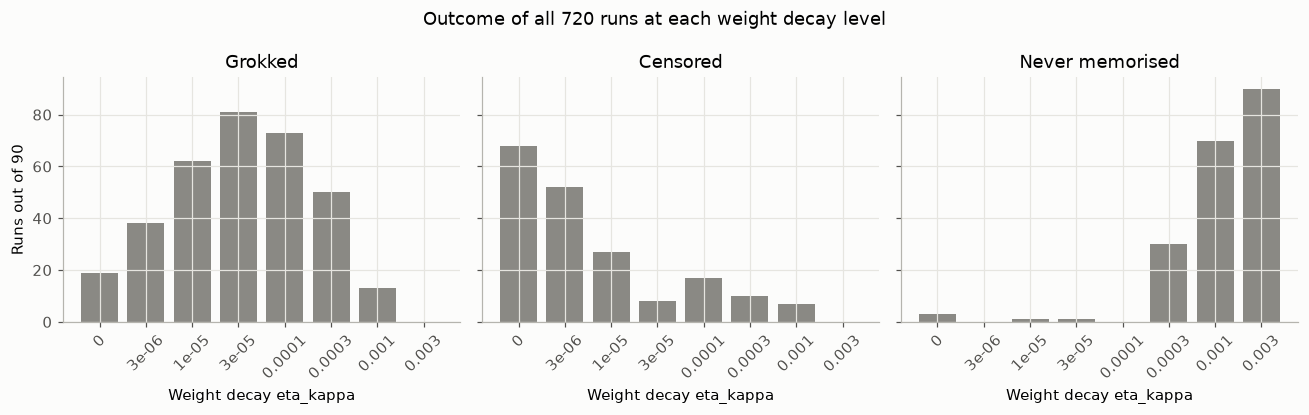

In [7]:
levels = outcome_by_wd.index
level_names = [f'{level:g}' for level in levels]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, outcome in zip(axes, outcomes):
    ax.bar(level_names, outcome_by_wd[outcome], color=GREY)
    ax.set_title(outcome.capitalize())
    ax.set_xlabel('Weight decay eta_kappa')
    ax.tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Runs out of 90')
fig.suptitle('Outcome of all 720 runs at each weight decay level')
plt.tight_layout()
plt.show()

**What the table and the plot show.**

- The number of grokked runs rises with weight decay up to 3e-5, where 81 of the 90 runs grok. Above 3e-5 it falls again.
- Without weight decay, 68 of the 90 runs are censored. They memorised but did not generalise within 200,000 steps. A small weight decay turns many of these runs into grokked runs.
- From 3e-4 upward, many runs never memorise. At 3e-3 none of the 90 runs memorise.

Now we keep only the runs that grokked and ask how long they took at each level.

In [8]:
grokked = runs[runs['outcome'] == 'grokked']
grokked.groupby('eta_kappa')['t_grok_acc100'].describe()[['count', 'min', '50%', 'max']].round(0)

,count,min,50%,max
eta_kappa,,,,
0.000000,19.0,2021.0,7317.0,66683.0
0.000003,38.0,2021.0,38024.0,197770.0
0.000010,62.0,1520.0,47206.0,173388.0
0.000030,81.0,2517.0,28815.0,173793.0
0.000100,73.0,1676.0,9570.0,151000.0
0.000300,50.0,1191.0,5074.0,18000.0
0.001000,13.0,1308.0,2280.0,4695.0


The column `50%` is the median grokking time. A plot shows the spread better. Each dot is one grokked run, and the black bar is the median of its level. The dots are spread a little sideways so they do not hide each other. The time axis is logarithmic, because the times range from about a thousand steps to about two hundred thousand.

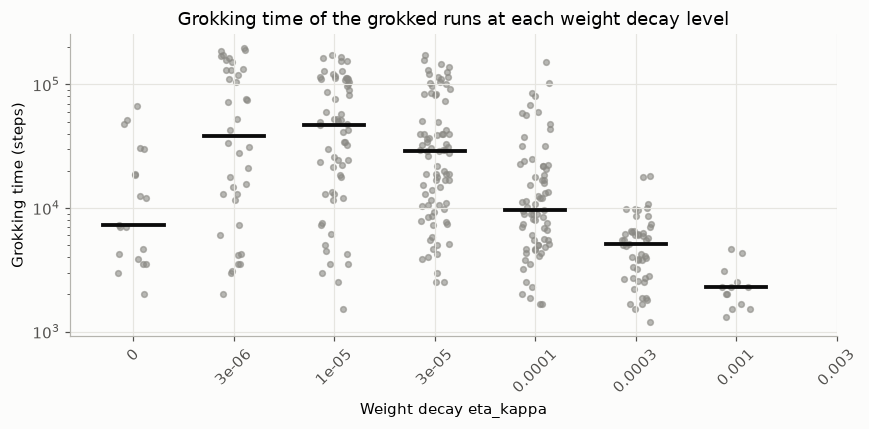

In [9]:
jitter = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 4))
for i, level in enumerate(levels):
    times = grokked.loc[grokked['eta_kappa'] == level, 't_grok_acc100']
    ax.scatter(i + jitter.uniform(-0.15, 0.15, len(times)), times, s=14, color=GREY, alpha=0.6)
    if len(times) > 0:
        ax.plot([i - 0.3, i + 0.3], [times.median()] * 2, color=INK, linewidth=2.5)
ax.set_xticks(range(len(levels)), level_names, rotation=45)
ax.set_yscale('log')
ax.set_xlabel('Weight decay eta_kappa')
ax.set_ylabel('Grokking time (steps)')
ax.set_title('Grokking time of the grokked runs at each weight decay level')
plt.tight_layout()
plt.show()

**What the plot shows.**

- From 1e-5 upward, more weight decay means faster grokking. The median falls from 47,206 steps at 1e-5 to 2,280 steps at 1e-3, a factor of about 20.
- At 3e-6 and 1e-5 many runs take more than 100,000 steps, close to the budget of 200,000.
- The level 0 looks fast, with a median of 7,317 steps. This comes from which runs are left. Without weight decay only 19 runs grokked, and the slow runs are among the 68 censored runs, which have no exact grokking time. Part 3 shows which runs these 19 are.

### Choose two groups

Weight decay changes both the outcome and the grokking time. If we mixed the levels, the weight decay would hide any effect of the kernel. So from here on we hold the weight decay fixed and study two levels, one at a time.

- **Weight decay 3e-5.** This level has the most grokked runs, 81 of its 90, so leaving out the other 9 changes little.
- **No weight decay.** This is the setting of the published baseline that the project reproduces, Kumar et al. (2024), Appendix 8.3 (arXiv:2310.06110v3). Only 19 of its 90 runs grokked, so Part 3 looks at which ones.

`WD_LABEL` and `NO_WD_LABEL` are the names the two groups get in tables and figures.

In [10]:
WD = 3e-5
WD_LABEL = 'weight decay 3e-5'
NO_WD_LABEL = 'no weight decay'

runs_wd = grokked[np.isclose(grokked['eta_kappa'], WD)]
runs_no_wd = grokked[grokked['eta_kappa'] == 0]
len(runs_wd), len(runs_no_wd)

(81, 19)

The dictionary `groups` holds each group under its label, with its colour. The side-by-side figures below loop over it. Its first entry is the group with weight decay, so that group always lands in the left panel. Later parts add more to each entry.

In [11]:
groups = {
    WD_LABEL: {'runs': runs_wd, 'colour': WD_COLOUR},
    NO_WD_LABEL: {'runs': runs_no_wd, 'colour': NO_WD_COLOUR},
}

## Part 3. The two groups side by side

**Runs in this part.** The 81 grokked runs in `runs_wd` on the left, and the 19 grokked runs in `runs_no_wd` on the right.

First we ask where each group groks. Each setting of `alpha` and width has 5 seeds. For each setting we count how many of its seeds grokked.

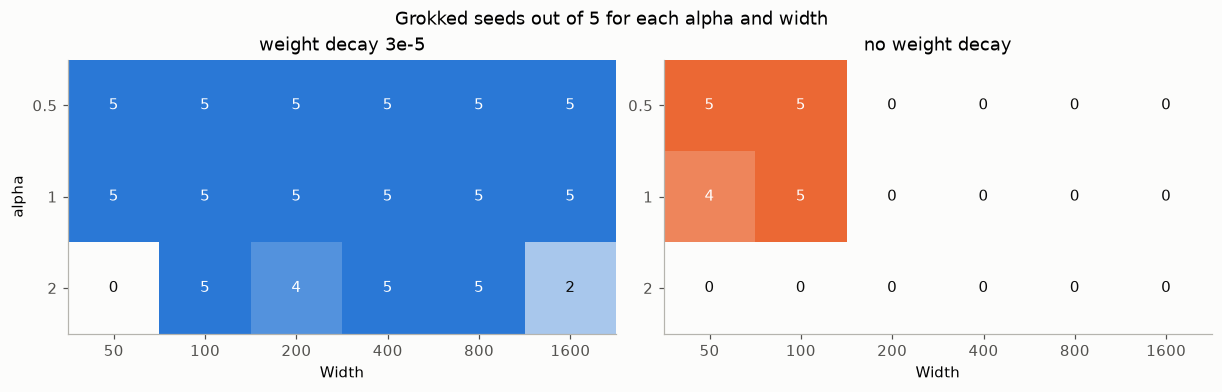

In [12]:
alphas = sorted(runs['alpha'].unique())
widths = sorted(runs['width'].unique())

def grok_counts(group_runs):
    table = pd.crosstab(group_runs['alpha'], group_runs['width'])
    return table.reindex(index=alphas, columns=widths, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), layout='constrained')
for ax, (label, group) in zip(axes, groups.items()):
    counts = grok_counts(group['runs'])
    ramp = LinearSegmentedColormap.from_list(label, [SURFACE, group['colour']])
    ax.imshow(counts, cmap=ramp, vmin=0, vmax=5)
    for i in range(len(alphas)):
        for j in range(len(widths)):
            n = counts.iloc[i, j]
            ax.text(j, i, n, ha='center', va='center', color='white' if n >= 4 else INK)
    ax.set_xticks(range(len(widths)), widths)
    ax.set_yticks(range(len(alphas)), [f'{a:g}' for a in alphas])
    ax.set_xlabel('Width')
    ax.set_title(label)
    ax.grid(False)
axes[0].set_ylabel('alpha')
fig.suptitle('Grokked seeds out of 5 for each alpha and width', y=1.06)
plt.show()

**What the plot shows.**

- With weight decay 3e-5, every setting at `alpha` 0.5 and 1 grokked with all 5 seeds. The 9 missing runs are all at `alpha` 2: all 5 seeds at width 50, one seed at width 200 and three seeds at width 1600.
- Without weight decay, only widths 50 and 100 at `alpha` 0.5 and 1 grokked. No run at `alpha` 2 and no run of width 200 or more grokked.
- So the 81 runs with weight decay cover 17 settings, and the 19 runs without weight decay cover only 4. Every comparison of the two groups below has to keep this in mind.

Next, how long each group takes. Each faint dot is one run. The line joins the median time at each width, with one line per value of `alpha`. Both panels use the same axes, so the right panel shows how few widths are left without weight decay.

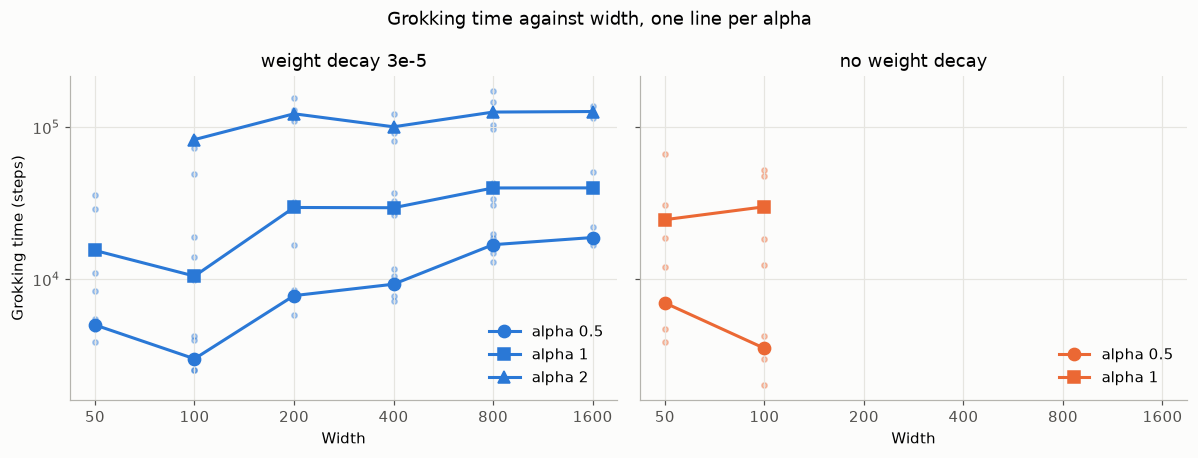

In [13]:
markers = {0.5: 'o', 1.0: 's', 2.0: '^'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for ax, (label, group) in zip(axes, groups.items()):
    for a, marker in markers.items():
        sub = group['runs'][group['runs']['alpha'] == a]
        if len(sub) == 0:
            continue
        ax.scatter(sub['width'], sub['t_grok_acc100'], s=12, color=group['colour'], alpha=0.35)
        medians = sub.groupby('width')['t_grok_acc100'].median()
        ax.plot(medians.index, medians.values, marker=marker, markersize=8,
                color=group['colour'], label=f'alpha {a:g}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(widths, [str(w) for w in widths])
    ax.minorticks_off()
    ax.set_xlabel('Width')
    ax.set_title(label)
    ax.legend(loc='lower right')
axes[0].set_ylabel('Grokking time (steps)')
fig.suptitle('Grokking time against width, one line per alpha')
plt.tight_layout()
plt.show()

**What the plot shows.**

- With weight decay 3e-5, `alpha` sets most of the grokking time. At every width, `alpha` 2 is the slowest and `alpha` 0.5 is the fastest. The medians run from about 3,000 steps at `alpha` 0.5 and width 100 to about 127,000 steps at `alpha` 2 and width 1600.
- Past width 100, wider networks grok more slowly. From width 100 to width 1600 the median time grows by a factor of about 6 at `alpha` 0.5 and about 4 at `alpha` 1.
- Without weight decay, the right panel is empty past width 100. At `alpha` 0.5 the times run from 2,021 to 7,317 steps. At `alpha` 1 the seeds spread widely, from 12,000 to 66,683 steps.

The two groups share only four settings: `alpha` 0.5 and 1 at widths 50 and 100. To compare the groups fairly we look at those four settings alone. The table gives the median grokking time of each group, and the ratio of the two.

In [14]:
def shared_medians(group_runs):
    shared = group_runs[group_runs['alpha'].isin([0.5, 1.0]) & group_runs['width'].isin([50, 100])]
    return shared.groupby(['alpha', 'width'])['t_grok_acc100'].agg(['count', 'median'])

shared_table = pd.concat({label: shared_medians(group['runs']) for label, group in groups.items()}, axis=1)
shared_table['no wd / wd'] = shared_table[(NO_WD_LABEL, 'median')] / shared_table[(WD_LABEL, 'median')]
shared_table.round(2)

weight decay 3e-5          no weight decay          no wd / wd
                        count   median           count   median           
alpha width                                                               
0.5   50                    5   5014.0               5   7000.0       1.40
      100                   5   3002.0               5   3520.0       1.17
1.0   50                    5  15487.0               4  24678.0       1.59
      100                   5  10504.0               5  30000.0       2.86

On all four shared settings, the runs without weight decay take longer. The ratio runs from 1.17 at `alpha` 0.5 and width 100 to 2.86 at `alpha` 1 and width 100. The setting at `alpha` 1 and width 50 has only 4 grokked runs without weight decay, because one seed was censored. Adding that slow seed could only raise the median, so the gap there may be larger.

So when the settings match, a weight decay of 3e-5 shortens the grokking time. The level 0 looked fast in Part 2 only because its slow runs never grokked.

## Part 4. One run from each group over time

**Runs in this part.** Two runs that differ in weight decay only. Both have `alpha` = 1, width 100 and seed 0.

| Variable | Run | Weight decay | Taken from |
| --- | --- | --- | --- |
| `id_wd` | `ntk_N100_a1_wd3e-05_s0` | 3e-5 | `runs_wd` |
| `id_no_wd` | `ntk_N100_a1_wd0_s0` | none | `runs_no_wd` |

The run without weight decay is the baseline of the project. It uses the settings of Kumar et al. (2024), Appendix 8.3 (arXiv:2310.06110v3): one hidden layer of width 100, learning rate 100, `p` = 23, 90 percent of the pairs for training, and no weight decay. In our runs the learning rate is 100 divided by `alpha` squared, so at `alpha` = 1 it is 100. The group's Tier 0 notebook, `repoduced-code/tier0_reproduction.ipynb`, reproduces this setting over 100,000 steps. Our run is the same setting over 200,000 steps.

Part 3 showed why we use width 100: without weight decay, no run at width 200 or wider grokked.

In [15]:
id_wd = 'ntk_N100_a1_wd3e-05_s0'
id_no_wd = 'ntk_N100_a1_wd0_s0'

events = pd.concat([
    runs_wd[runs_wd['run_id'] == id_wd],
    runs_no_wd[runs_no_wd['run_id'] == id_no_wd],
])[['run_id'] + settings + ['t_mem', 't_gen_acc100', 't_grok_acc100']]
events.index = [WD_LABEL, NO_WD_LABEL]
events

,run_id,alpha,width,eta_kappa,seed,t_mem,t_gen_acc100,t_grok_acc100
weight decay 3e-5,ntk_N100_a1_wd3e-05_s0,1.0,100,0.00003,0,4496.0,15000.0,10504.0
no weight decay,ntk_N100_a1_wd0_s0,1.0,100,0.00000,0,4496.0,17000.0,12504.0


Each row is one run, named by its label. The two runs have the same `alpha`, width and seed, and only `eta_kappa` differs. Both runs memorise at the same checkpoint, step 4,496. The run with weight decay reaches a test accuracy of 1 at step 15,000, and the run without it at step 17,000. So a weight decay of 3e-5 shortens the grokking time here from 12,504 to 10,504 steps, by about 16 percent.

Part 3 found a median ratio of 2.86 at this setting. So seed 0 is a pair in which weight decay helps less than it does for most seeds.

Now we read the checkpoints of each run. The `filters` argument reads just the rows of one run from the large file.

In [16]:
curve_cols = ['step', 'train_acc', 'test_acc', 'A_t', 'S_c', 'R_c']

def read_curves(run_id):
    return pd.read_parquet('data/checkpoints.parquet', columns=curve_cols,
                           filters=[('run_id', '==', run_id)])

curves_wd = read_curves(id_wd)
curves_no_wd = read_curves(id_no_wd)
len(curves_wd), len(curves_no_wd)

(307, 307)

Each run has 307 checkpoints. The dictionary `two_runs` holds what the plots need about each run, under the same labels as `groups`. `mark_events` draws two dotted grey lines in a panel: one where the run memorised and one where it generalised.

In [17]:
two_runs = {
    WD_LABEL: {'curves': curves_wd, 'events': events.loc[WD_LABEL], 'colour': WD_COLOUR},
    NO_WD_LABEL: {'curves': curves_no_wd, 'events': events.loc[NO_WD_LABEL], 'colour': NO_WD_COLOUR},
}

def mark_events(ax, run, names=False):
    for event, name, align in [('t_mem', 'memorised ', 'right'), ('t_gen_acc100', ' generalised', 'left')]:
        ax.axvline(run['events'][event], color=GREY, linestyle=':', linewidth=1.5)
        if names:
            ax.text(run['events'][event], 1.02, name, transform=ax.get_xaxis_transform(),
                    ha=align, va='bottom', fontsize=8, color='#52514e')

First the two accuracies, to see the grokking itself. The dashed line is the train accuracy and the solid line is the test accuracy. The step axis is logarithmic, so step 0 is not shown.

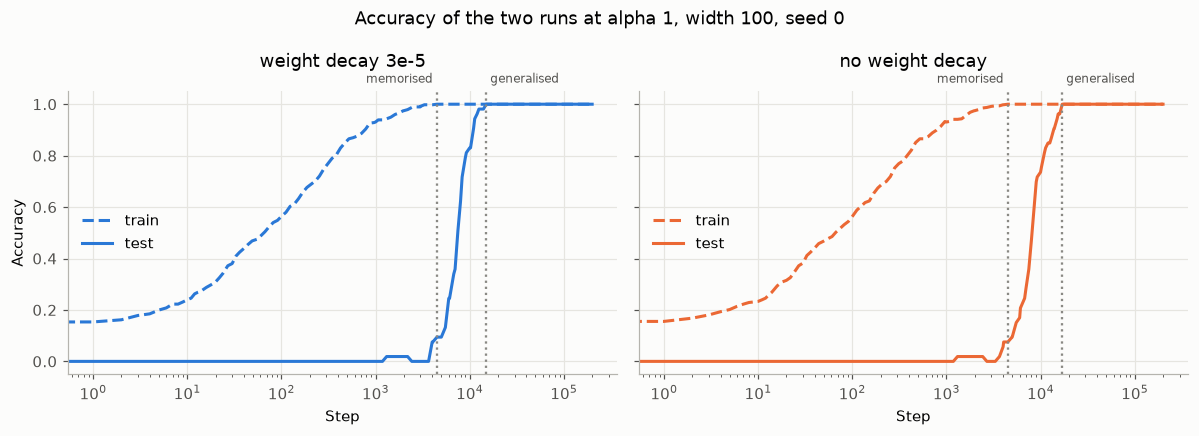

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, (label, run) in zip(axes, two_runs.items()):
    ax.plot(run['curves']['step'], run['curves']['train_acc'], color=run['colour'],
            linestyle='--', label='train')
    ax.plot(run['curves']['step'], run['curves']['test_acc'], color=run['colour'], label='test')
    mark_events(ax, run, names=True)
    ax.set_xscale('log')
    ax.set_xlabel('Step')
    ax.set_title(label, pad=16)
    ax.legend(loc='center left')
axes[0].set_ylabel('Accuracy')
fig.suptitle('Accuracy of the two runs at alpha 1, width 100, seed 0')
plt.tight_layout()
plt.show()

**What the plot shows.** In both panels the train accuracy climbs to 1 by step 4,496, and the test accuracy stays near 0 until about step 3,000. Then the test accuracy climbs. It reaches 1 at step 15,000 with weight decay and at step 17,000 without it. At this setting the two runs look almost the same.

Now the three kernel numbers. Each row is one number and each column is one run. The panels in a row share their vertical axis, so the two runs can be read against each other. Each panel also shows the other run as a thin grey line, which makes the difference easier to see. `names` maps each data column to the name the report uses, and later parts use it too.

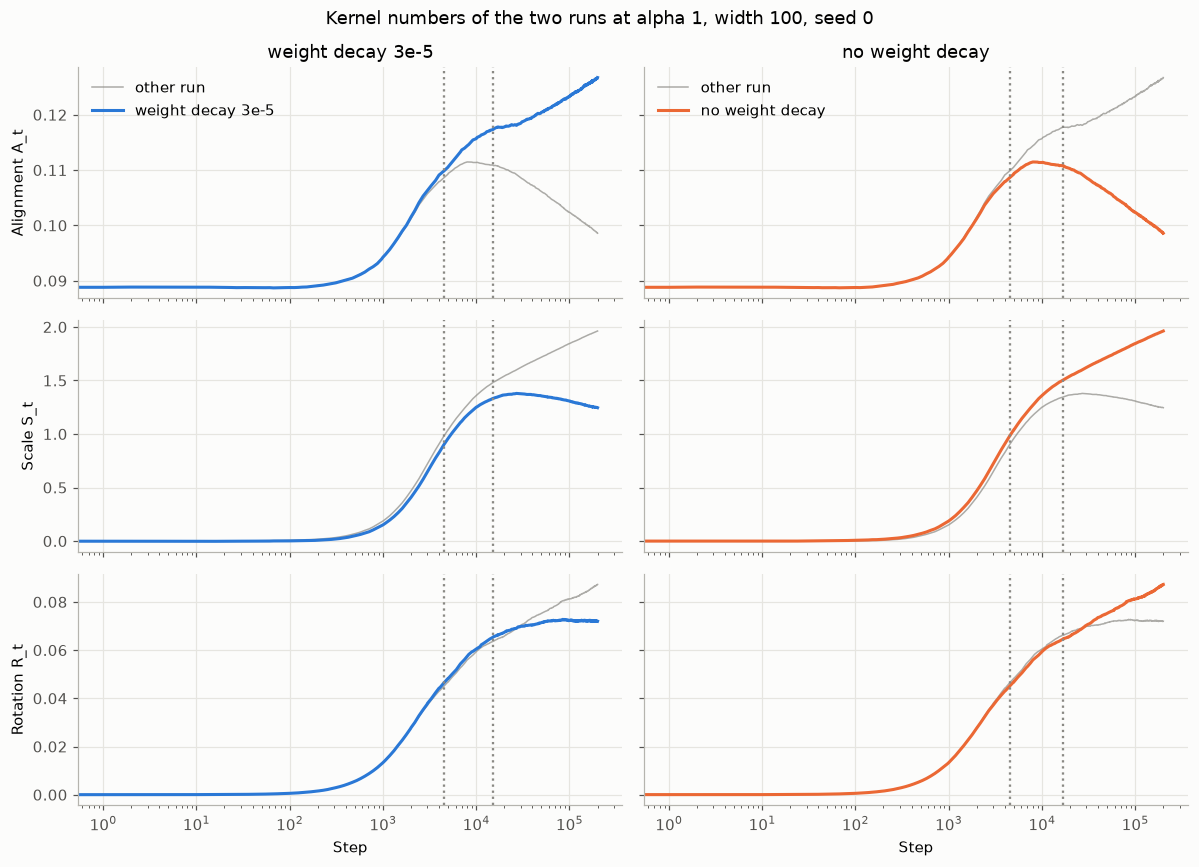

In [19]:
names = {'A_t': 'A_t', 'S_c': 'S_t', 'R_c': 'R_t'}
panels = [('A_t', 'Alignment A_t'), ('S_c', 'Scale S_t'), ('R_c', 'Rotation R_t')]

fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, sharey='row')
for col_axes, (label, run) in zip(axes.T, two_runs.items()):
    other = [r for l, r in two_runs.items() if l != label][0]
    for ax, (col, name) in zip(col_axes, panels):
        ax.plot(other['curves']['step'], other['curves'][col], color=GREY, linewidth=1,
                alpha=0.7, label='other run')
        ax.plot(run['curves']['step'], run['curves'][col], color=run['colour'], label=label)
        mark_events(ax, run)
    col_axes[0].set_title(label)
    col_axes[0].legend(loc='upper left')
    col_axes[-1].set_xscale('log')
    col_axes[-1].set_xlabel('Step')
for ax, (col, name) in zip(axes[:, 0], panels):
    ax.set_ylabel(name)
fig.suptitle('Kernel numbers of the two runs at alpha 1, width 100, seed 0')
plt.tight_layout()
plt.show()

To read exact values, we print the three numbers at a few steps. The rows are grouped by run, and each column is one step.

In [20]:
steps = [2000, 5000, 10000, 15000, 17000, 30000, 100000, 200000]

def at_steps(curves):
    return curves.set_index('step').loc[steps, ['A_t', 'S_c', 'R_c']].rename(columns=names)

kernel_table = pd.concat({label: at_steps(run['curves']) for label, run in two_runs.items()}, axis=1)
kernel_table.round(3).T

step                   2000    5000    10000   15000   17000   30000   100000  \
weight decay 3e-5 A_t   0.102   0.111   0.116   0.117   0.118   0.118   0.123   
                  S_t   0.408   0.959   1.250   1.331   1.346   1.377   1.309   
                  R_t   0.028   0.048   0.060   0.065   0.066   0.070   0.072   
no weight decay   A_t   0.101   0.109   0.111   0.111   0.111   0.109   0.102   
                  S_t   0.469   1.038   1.359   1.478   1.506   1.621   1.844   
                  R_t   0.028   0.047   0.059   0.064   0.065   0.070   0.081   

step                   200000  
weight decay 3e-5 A_t   0.127  
                  S_t   1.246  
                  R_t   0.072  
no weight decay   A_t   0.099  
                  S_t   1.962  
                  R_t   0.087

**What the plots and the table show.**

- All three numbers start to move a few hundred steps into training, well before the test accuracy climbs. This is why Part 5 can read them early.
- Before generalisation the two runs are close. At step 2,000, `A_t` is 0.102 with weight decay and 0.101 without it, and `R_t` is 0.028 in both. `S_t` grows a little more slowly with weight decay, 0.41 against 0.47.
- **Scale.** Without weight decay, `S_t` keeps rising for the whole run and ends at 1.96. The kernel then ends about 7 times its starting size, since e^1.96 ≈ 7.1. With weight decay, `S_t` peaks at 1.38 near step 27,000 and then falls to 1.25 as the decay shrinks the weights.
- **Alignment.** Without weight decay, `A_t` peaks at 0.111 near step 8,000, before the run generalises. It then falls to 0.099 by the end. With weight decay, `A_t` keeps rising through the whole run, to 0.127.
- **Rotation.** Both runs reach about 0.07 by step 30,000. Without weight decay `R_t` keeps rising, to 0.087. With weight decay it levels off at about 0.072.

In this pair, weight decay moves the grokking time by only 2,000 steps. Its larger effect on the kernel comes after grokking. This is one pair of runs with one seed, so treat it as an example of what can happen.

## Part 5. The kernel at step 2,000 in both groups

**Runs in this part.** All 81 runs in `runs_wd` on the left, and all 19 runs in `runs_no_wd` on the right.

Part 4 showed that the kernel starts to move well before the test accuracy climbs. So we ask whether the kernel early in a run goes with how long that run takes to grok. We read the three kernel numbers at step 2,000 and set them against the grokking time.

Why step 2,000? The numbers must be measured before the run generalises. Otherwise they could carry the answer. We check the earliest generalisation in each group.

In [21]:
pd.Series({label: group['runs']['t_gen_acc100'].min() for label, group in groups.items()},
          name='earliest t_gen_acc100')

weight decay 3e-5    4496.0
no weight decay      4000.0
Name: earliest t_gen_acc100, dtype: float64

The earliest run to generalise does so at step 4,496 with weight decay and at step 4,000 without it. So at step 2,000 every run in both groups is still before generalisation.

We read the three kernel numbers at step 2,000 for every run in the dataset. `with_inputs` joins them to one group, which keeps only that group's runs. It also adds the target `log_t`, the log, base 10, of the grokking time. A log time of 4 means 10,000 steps.

In [22]:
inputs = ['A_t', 'S_c', 'R_c']
step2000 = pd.read_parquet('data/checkpoints.parquet', columns=['run_id'] + inputs,
                           filters=[('step', '==', 2000)])

def with_inputs(group_runs):
    data = group_runs[['run_id', 'alpha', 'width', 't_grok_acc100']].merge(step2000, on='run_id')
    data['log_t'] = np.log10(data['t_grok_acc100'])
    return data

data_wd = with_inputs(runs_wd)
data_no_wd = with_inputs(runs_no_wd)
groups[WD_LABEL]['data'] = data_wd
groups[NO_WD_LABEL]['data'] = data_no_wd
len(data_wd), len(data_no_wd)

(81, 19)

In [23]:
data_wd.head()

,run_id,alpha,width,t_grok_acc100,A_t,S_c,R_c,log_t
0,ntk_N50_a0.5_wd3e-05_s0,0.5,50,3846.0,0.114363,1.297089,0.121506,3.585009
1,ntk_N50_a0.5_wd3e-05_s1,0.5,50,5504.0,0.107443,1.317524,0.120045,3.740678
2,ntk_N50_a0.5_wd3e-05_s2,0.5,50,4695.0,0.109525,1.327886,0.105401,3.671636
3,ntk_N50_a0.5_wd3e-05_s3,0.5,50,5160.0,0.112016,1.289952,0.116189,3.712650
4,ntk_N50_a0.5_wd3e-05_s4,0.5,50,5014.0,0.114281,1.391829,0.117500,3.700184


Each input against the target, for both groups. Each row of panels is one input, and each column is one group. The panels in a row share their horizontal axis, and every panel shares the vertical axis. The marker shape shows `alpha`, as in Part 3.

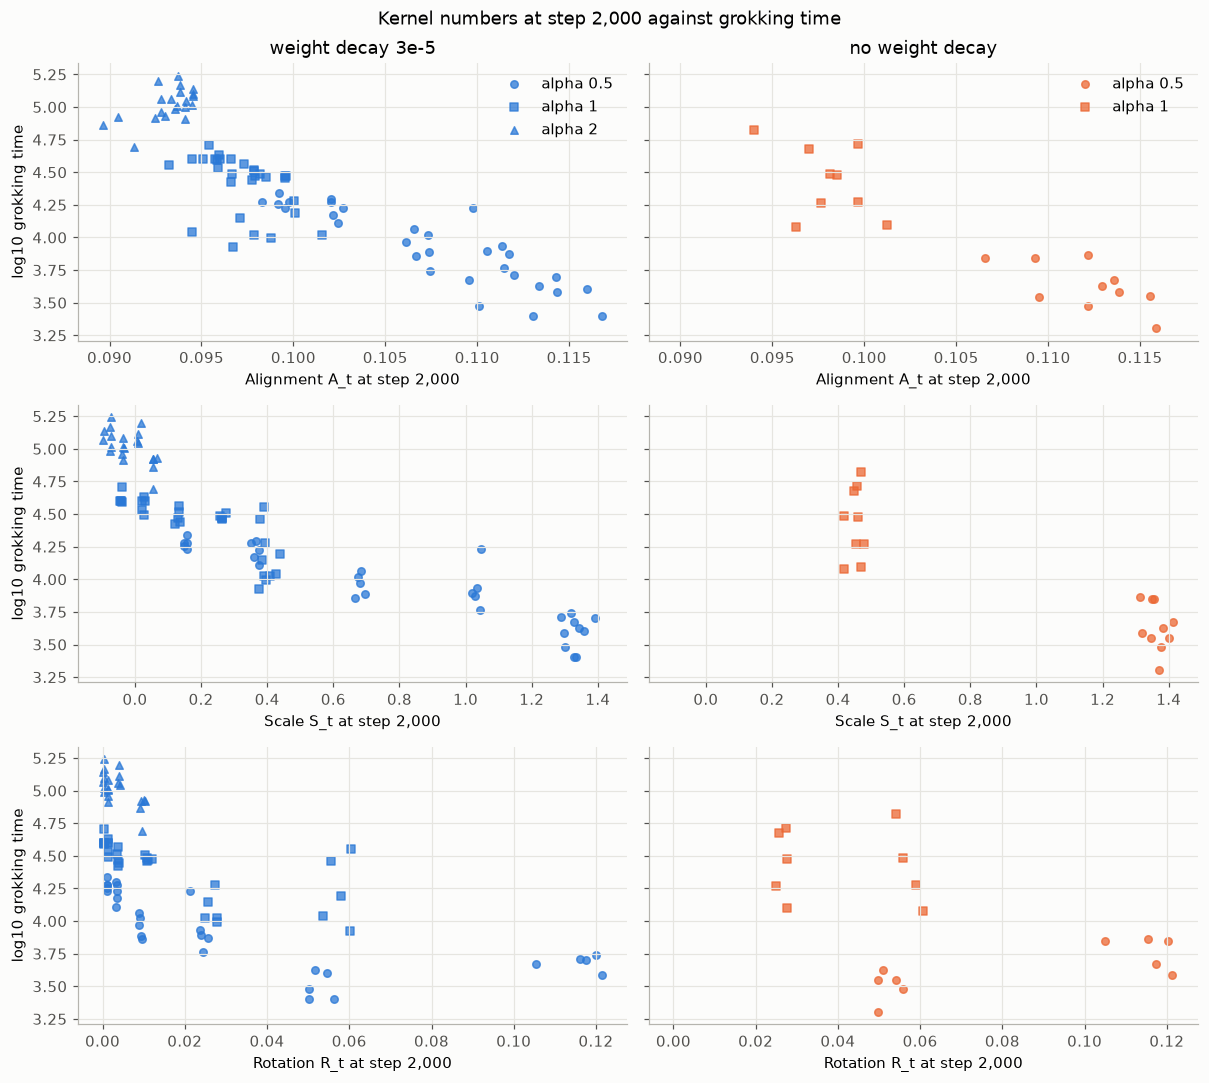

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(11, 10), sharex='row', sharey=True)
for col_axes, (label, group) in zip(axes.T, groups.items()):
    for ax, (col, name) in zip(col_axes, panels):
        for a, marker in markers.items():
            sub = group['data'][group['data']['alpha'] == a]
            if len(sub) > 0:
                ax.scatter(sub[col], sub['log_t'], s=24, marker=marker, color=group['colour'],
                           alpha=0.75, label=f'alpha {a:g}')
        ax.set_xlabel(f'{name} at step 2,000')
    col_axes[0].set_title(label)
    col_axes[0].legend(loc='upper right')
for ax in axes[:, 0]:
    ax.set_ylabel('log10 grokking time')
fig.suptitle('Kernel numbers at step 2,000 against grokking time')
plt.tight_layout()
plt.show()

**What the plot shows.**

- In both groups, all three inputs go down as the grokking time goes up. Runs whose kernel has already moved more by step 2,000 grok sooner.
- The points form clusters by `alpha`. With weight decay, the three values of `alpha` sit in three bands of grokking time, and the kernel numbers differ between the bands. So part of the link may come from the settings, which shape both the early kernel and the grokking time.
- Without weight decay, the 19 runs form two clusters, one per `alpha`. At `alpha` 0.5, `S_t` is near 1.35 and the times are short. At `alpha` 1, `S_t` is near 0.45 and the times are long. Inside each cluster there is little trend. So in this group the link rests mostly on the gap between the two clusters.
- With weight decay, many slow runs have a rotation near 0 at step 2,000. So the rotation mostly tells the fast runs apart from the rest.

A correlation puts a number on each of these links. The table gives the correlations within each group, with the group names on top.

In [25]:
pd.concat({label: group['data'][inputs + ['log_t']].rename(columns=names).corr()
           for label, group in groups.items()}, axis=1).round(2)

weight decay 3e-5                   no weight decay                  
                    A_t   S_t   R_t log_t             A_t   S_t   R_t log_t
A_t                1.00  0.94  0.60 -0.88            1.00  0.95  0.52 -0.91
S_t                0.94  1.00  0.77 -0.88            0.95  1.00  0.63 -0.88
R_t                0.60  0.77  1.00 -0.64            0.52  0.63  1.00 -0.45
log_t             -0.88 -0.88 -0.64  1.00           -0.91 -0.88 -0.45  1.00

Each input has a negative correlation with `log_t` in both groups. `A_t` has the strongest, -0.88 with weight decay and -0.91 without it. `R_t` has the weakest, -0.64 and -0.45.

The inputs are also strongly correlated with each other. `A_t` and `S_t` have a correlation of 0.94 with weight decay and 0.95 without it. When two inputs move together this closely, a model cannot tell which of them matters. Part 6 shows what this does to a fitted line.

## Part 6. A straight line for each group

**Runs in this part.** All 81 runs in `data_wd` in the first section, and all 19 runs in `data_no_wd` in the second. The third section puts the two fits side by side.

Part 5 showed that each input goes with the grokking time. A straight line fitted to all three at once tells us what each input adds when the other two are held fixed. We fit a linear model by ordinary least squares, often shortened to OLS:

`log_t = intercept + b_A * A_t + b_S * S_t + b_R * R_t`

The three inputs have very different sizes. `A_t` moves by about 0.01, while `S_t` moves by about 1. `standardise` rescales each input to mean 0 and standard deviation 1. Each coefficient is then the change in log time for one standard deviation of that input, and the three coefficients can be compared. `standardise` also renames `S_c` and `R_c` to the report's names with `names` from Part 4.

`fit_line` standardises the inputs of one group with that group's own mean and standard deviation, then fits the line. `sm.add_constant` adds a column of ones to the inputs, which gives the model its intercept. In this part each line is fitted on every run of its group, so it describes the group. Part 7 asks whether a line can predict runs it has not seen.

In [26]:
def standardise(df, ref):
    z = (df[inputs] - ref[inputs].mean()) / ref[inputs].std()
    return z.rename(columns=names)

def fit_line(data):
    return sm.OLS(data['log_t'], sm.add_constant(standardise(data, data))).fit()

### The runs with weight decay 3e-5

In [27]:
ols_all_wd = fit_line(data_wd)
ols_all_wd.summary(title=f'OLS fitted on all {len(data_wd)} runs with {WD_LABEL}')

<class 'statsmodels.iolib.summary.Summary'>
"""
               OLS fitted on all 81 runs with weight decay 3e-5               
==============================================================================
Dep. Variable:                  log_t   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                     102.9
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           7.33e-27
Time:                        18:33:30   Log-Likelihood:                 9.0918
No. Observations:                  81   AIC:                            -10.18
Df Residuals:                      77   BIC:                           -0.6058
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3913      0.025    178.167      0.000       4.342       4.440
A_t           -0.2328      0.093     -2.509      0.014      -0.418      -0.048
S_t           -0.1935      0.117     -1.652      0.103      -0.427       0.040
R_t           -0.0221      0.049     -0.448      0.655      -0.120       0.076
==============================================================================
Omnibus:                        0.122   Durbin-Watson:                   1.150
Prob(Omnibus):                  0.941   Jarque-Bera (JB):                0.310
Skew:                          -0.019   Prob(JB):                        0.856
Kurtosis:                       2.699   Cond. No.                         9.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**How to read the summary.** These are the parts that matter here.

- `coef` is the fitted coefficient. The intercept, `const`, is 4.39. It is the mean log time, near 25,000 steps, since 10^4.39 ≈ 24,600. `A_t` has a coefficient of -0.23 and `S_t` has -0.19. One standard deviation more of `A_t` predicts a grokking time about 1.7 times shorter, since 10^0.23 ≈ 1.7. `R_t` has a coefficient near 0, at -0.02.
- `std err` is the uncertainty of each coefficient. `[0.025` and `0.975]` are the ends of its 95 percent confidence interval. The interval for `R_t` runs from -0.12 to 0.08, so even its sign is unknown. The interval for `S_t` runs from -0.43 to 0.04, so it also includes 0.
- `P>|t|` is the p-value for the hypothesis that the coefficient is 0. It is 0.01 for `A_t`, 0.10 for `S_t` and 0.66 for `R_t`.
- `R-squared` is the share of the spread in the grokking times that the line explains. It is 0.80 here.
- `Prob (F-statistic)` tests all three inputs together. It is about 7e-27, so together the inputs are clearly linked to the time.

So `S_t` and `R_t` look weak on their own, while the three inputs together are strong. This is the correlation of 0.94 between `A_t` and `S_t` from Part 5 at work. The pair predicts well, but the model cannot split the credit between them, so each one gets a wide interval.

The standard errors also assume that every run is independent of the others. The 5 seeds of one setting are near twins, so the real uncertainty is larger than the table shows and the p-values are too small.

### The runs without weight decay

In [28]:
ols_all_no_wd = fit_line(data_no_wd)
ols_all_no_wd.summary(title=f'OLS fitted on all {len(data_no_wd)} runs with {NO_WD_LABEL}')

<class 'statsmodels.iolib.summary.Summary'>
"""
                OLS fitted on all 19 runs with no weight decay                
==============================================================================
Dep. Variable:                  log_t   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     25.80
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           3.59e-06
Time:                        18:33:30   Log-Likelihood:                 5.2981
No. Observations:                  19   AIC:                            -2.596
Df Residuals:                      15   BIC:                             1.182
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0112      0.047     84.850      0.000       3.910       4.112
A_t           -0.3178      0.163     -1.952      0.070      -0.665       0.029
S_t           -0.1371      0.178     -0.768      0.454      -0.518       0.243
R_t            0.0432      0.066      0.658      0.521      -0.097       0.183
==============================================================================
Omnibus:                        1.481   Durbin-Watson:                   2.455
Prob(Omnibus):                  0.477   Jarque-Bera (JB):                0.400
Skew:                          -0.303   Prob(JB):                        0.819
Kurtosis:                       3.373   Cond. No.                         7.66
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The same table for the 19 runs without weight decay.

- The intercept is 4.01, a mean near 10,000 steps. It is lower than with weight decay because only the small, fast settings grokked.
- `A_t` has the largest coefficient, -0.32, with a p-value of 0.07. `S_t` has -0.14 and `R_t` has +0.04. Every interval includes 0.
- `R-squared` is 0.84, a little higher than with weight decay. A higher R squared here says little about the fit. Part 5 showed two clusters, one per `alpha`, and a line explains much of the spread just by separating them.
- The fit rests on 19 runs from 4 settings, with 3 inputs. The seeds of one setting are near twins, so the 19 runs carry much less information than 19 independent runs would.

### The two fits side by side

We store each fit in `groups` and plot the three coefficients of each group with their 95 percent intervals. An interval that crosses the grey line at 0 means the data cannot tell the sign of that coefficient.

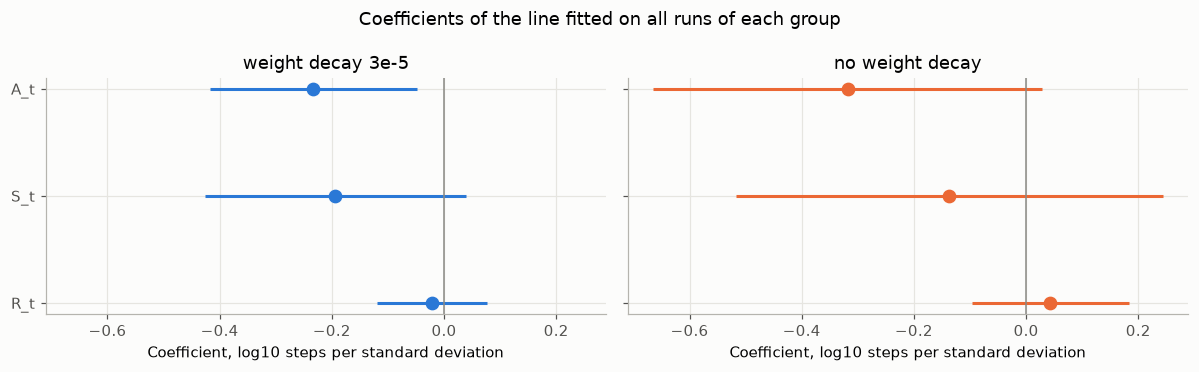

In [29]:
groups[WD_LABEL]['ols_all'] = ols_all_wd
groups[NO_WD_LABEL]['ols_all'] = ols_all_no_wd

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharex=True, sharey=True)
for ax, (label, group) in zip(axes, groups.items()):
    coef = group['ols_all'].params.drop('const')
    low, high = group['ols_all'].conf_int().drop('const').T.to_numpy()
    y = np.arange(len(coef))
    ax.errorbar(coef, y, xerr=[coef - low, high - coef], fmt='o', markersize=8,
                color=group['colour'], linewidth=2)
    ax.axvline(0, color=GREY, linewidth=1)
    ax.set_yticks(y, coef.index)
    ax.set_xlabel('Coefficient, log10 steps per standard deviation')
    ax.set_title(label)
axes[0].invert_yaxis()
fig.suptitle('Coefficients of the line fitted on all runs of each group')
plt.tight_layout()
plt.show()

A small table of what each fit rests on. Each row is one group.

In [30]:
pd.DataFrame.from_dict({
    label: {
        'runs': int(group['ols_all'].nobs),
        'settings of alpha and width': group['data'].groupby(['alpha', 'width']).ngroups,
        'R squared': group['ols_all'].rsquared,
    }
    for label, group in groups.items()
}, orient='index').round(2)

,runs,settings of alpha and width,R squared
weight decay 3e-5,81,17,0.80
no weight decay,19,4,0.84


**What the two fits show.**

- In both groups `A_t` has the largest coefficient, and it is negative. A kernel that is better aligned at step 2,000 goes with a shorter grokking time.
- `S_t` is negative in both groups, and its interval includes 0 in both.
- `R_t` is near 0 in both groups, with opposite signs, -0.02 and +0.04. Neither sign is clear.
- The intervals without weight decay are wider, up to about twice as wide, because that group has 19 runs instead of 81.
- The line explains 80 percent of the spread with weight decay and 84 percent without it. The second number comes from 4 settings.

Each group is standardised with its own mean and standard deviation. So one standard deviation of `A_t` is a different amount in each group. The comparison is good for the sign and the rough size of each coefficient, and it cannot compare exact values.

## Part 7. Predict the grokking time of new runs with weight decay 3e-5

**Runs in this part.** Only the 81 runs in `data_wd`. No run without weight decay is used. Every variable in this part that holds runs or a fitted model ends in `_wd`.

Part 6 fitted each line on every run of its group, and a line always looks better on the runs it learned from. The fair test is to hide some runs, fit on the rest, and predict the hidden ones. We do this only for the group with weight decay 3e-5. The group without weight decay has 19 runs, so a test set of 20 percent would hold 4 runs, which is too few to score a model.

### Train and test split

We put 80 percent of the runs in a training set and keep 20 percent aside as a test set. The models learn from the training set only. The random seed makes the split the same every time the notebook runs.

In [31]:
rng = np.random.default_rng(0)
order = rng.permutation(len(data_wd))
n_train = int(0.8 * len(data_wd))
train_wd = data_wd.iloc[order[:n_train]]
test_wd = data_wd.iloc[order[n_train:]]
len(train_wd), len(test_wd)

(64, 17)

We standardise both sets with the mean and standard deviation of the training set. The test set must not affect the scaling, because the models may not see it before they are scored.

In [32]:
X_train_wd, X_test_wd = standardise(train_wd, train_wd), standardise(test_wd, train_wd)
y_train_wd, y_test_wd = train_wd['log_t'], test_wd['log_t']
X_train_wd.head()

,A_t,S_t,R_t
68,-0.732745,-0.924591,-0.663995
5,-0.433229,-0.004977,1.155237
50,-0.792585,-0.853867,-0.636676
67,-0.864107,-0.932373,-0.664099
53,-0.731941,-0.855720,-0.638530


### Three models: least squares, L1 and L2

Model 1 is the straight line of Part 6, now fitted on the training runs only.

Least squares picks the coefficients that make the squared errors on the training set as small as possible. A penalised model adds a cost for large coefficients to those errors. The cost pulls the coefficients toward 0. This can help when a model has learned noise in the training set, and it changes how the model splits the weight between inputs that move together. Part 5 showed that `A_t` and `S_t` move together. There are two common penalties.

- **L1, also called the lasso**, adds the sum of the absolute values of the coefficients. It can set a coefficient to exactly 0, which drops that input from the model. Among inputs that move together, it tends to keep one and drop the others. This is Model 2.
- **L2, also called ridge**, adds the sum of the squared coefficients. It shrinks every coefficient toward 0 but rarely to exactly 0. Among inputs that move together, it tends to share the weight between them. This is Model 3.

Each penalty has a strength, which scikit-learn calls `alpha`. This `alpha` has nothing to do with the laziness setting `alpha` of the runs. A strength of 0 gives back least squares, and a large strength pushes every coefficient to 0.

`LassoCV` and `RidgeCV` choose the strength by 5-fold cross-validation on the training set. They split the 64 training runs into 5 parts. For each strength they fit on 4 parts and score on the fifth, once for each part, and they keep the strength with the smallest average error. The test set plays no part in this.

statsmodels can also fit these penalties, with `fit_regularized`. It does not choose the strength for us, though, and it gives no summary table for a penalised fit. So we use scikit-learn for Models 2 and 3.

In [33]:
ols_wd = sm.OLS(y_train_wd, sm.add_constant(X_train_wd)).fit()
lasso_wd = LassoCV(cv=5).fit(X_train_wd, y_train_wd)
ridge_wd = RidgeCV(alphas=np.logspace(-3, 3, 61), cv=5).fit(X_train_wd, y_train_wd)
print(f'Runs with {WD_LABEL}')
print('L1 strength chosen:', round(lasso_wd.alpha_, 4))
print('L2 strength chosen:', round(ridge_wd.alpha_, 2))

Runs with weight decay 3e-5
L1 strength chosen: 0.0169
L2 strength chosen: 3.16


The two models measure the penalty on different scales, so the two strengths cannot be compared with each other.

To see what each penalty does, we refit each model over a range of strengths and plot the three coefficients. The dashed line marks the strength that cross-validation chose. At the left end the penalty is weak and the coefficients match least squares. At the right end it is strong and every coefficient reaches 0.

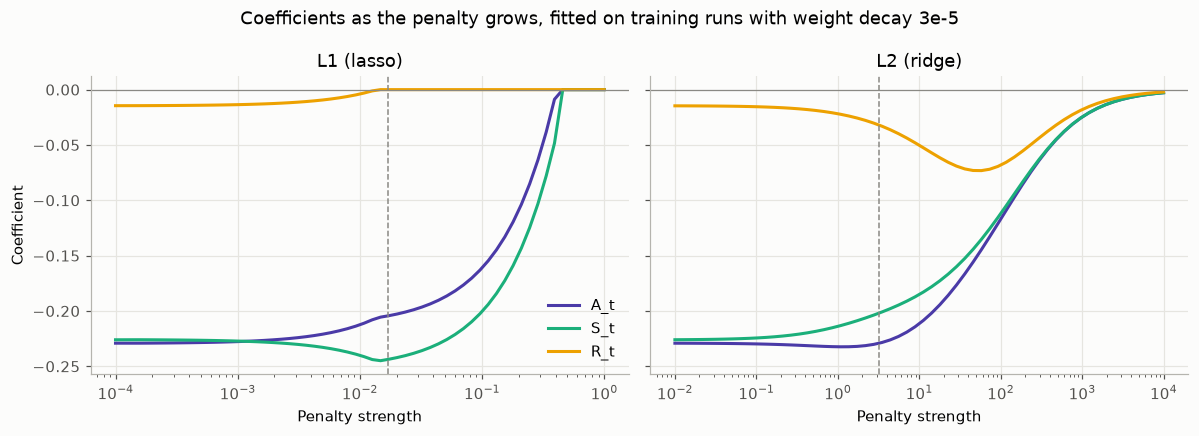

In [34]:
l1_strengths = np.logspace(-4, 0, 60)
l2_strengths = np.logspace(-2, 4, 60)
l1_path_wd = pd.DataFrame([Lasso(alpha=a).fit(X_train_wd, y_train_wd).coef_ for a in l1_strengths],
                          index=l1_strengths, columns=X_train_wd.columns)
l2_path_wd = pd.DataFrame([Ridge(alpha=a).fit(X_train_wd, y_train_wd).coef_ for a in l2_strengths],
                          index=l2_strengths, columns=X_train_wd.columns)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, path, model, title in [(axes[0], l1_path_wd, lasso_wd, 'L1 (lasso)'),
                               (axes[1], l2_path_wd, ridge_wd, 'L2 (ridge)')]:
    for col in path.columns:
        ax.plot(path.index, path[col], color=INPUT_COLOURS[col], label=col)
    ax.axvline(model.alpha_, color=GREY, linestyle='--', linewidth=1)
    ax.axhline(0, color=GREY, linewidth=0.8)
    ax.set_xscale('log')
    ax.set_xlabel('Penalty strength')
    ax.set_title(title)
axes[0].set_ylabel('Coefficient')
axes[0].legend()
fig.suptitle(f'Coefficients as the penalty grows, fitted on training runs with {WD_LABEL}')
plt.tight_layout()
plt.show()

**What the plot shows.**

- In the L1 panel, `R_t` is the first coefficient to reach 0, close to the strength that cross-validation chose. As `R_t` leaves, `S_t` becomes a little more negative and takes over its share. `A_t` reaches 0 near a strength of 0.4, and `S_t` is the last input left.
- In the L2 panel, no coefficient reaches 0 until the penalty is very strong. As the penalty grows, `R_t` first becomes more negative, down to about -0.07. Ridge moves weight from `S_t` onto `R_t`, because the two move together. At large strengths `A_t` and `S_t` shrink together with almost equal coefficients.
- The chosen strengths sit near the left end of both panels. So the two penalised models stay close to least squares.

The fitted coefficients of the three models side by side, all fitted on the training runs with weight decay 3e-5.

In [35]:
coefs_wd = pd.DataFrame({
    'OLS': ols_wd.params.to_numpy(),
    'L1 (lasso)': np.r_[lasso_wd.intercept_, lasso_wd.coef_],
    'L2 (ridge)': np.r_[ridge_wd.intercept_, ridge_wd.coef_],
}, index=['intercept', 'A_t', 'S_t', 'R_t'])
coefs_wd.round(3)

,OLS,L1 (lasso),L2 (ridge)
intercept,4.402,4.402,4.402
A_t,-0.229,-0.204,-0.229
S_t,-0.226,-0.244,-0.202
R_t,-0.015,-0.000,-0.032


The least-squares coefficients are close to those of Part 6, which used all 81 runs. The penalties that cross-validation chose are weak, so the coefficients move only a little. L1 sets `R_t` to exactly 0 and gives a little more weight to `S_t`. L2 takes some weight from `S_t` and moves it to `R_t`.

The intercept is the same in all three models. The inputs have mean 0 on the training set and the intercept carries no penalty, so it stays at the mean log time.

### Check the models on the test runs

We compare the three models with a baseline that ignores the inputs and always guesses the mean log time of the training set.

- **R squared** is the share of the spread in the test times that a model explains. 1 is perfect, and 0 is no better than the baseline.
- **Mean absolute error** is the typical distance between the prediction and the truth, in log10 units.
- **Typical factor off** turns that error back into steps. A factor of 2 means the prediction is typically off by a factor of two.

In [36]:
preds_wd = {
    'OLS': ols_wd.predict(sm.add_constant(X_test_wd)),
    'L1 (lasso)': lasso_wd.predict(X_test_wd),
    'L2 (ridge)': ridge_wd.predict(X_test_wd),
    'guess the mean': np.full(len(y_test_wd), y_train_wd.mean()),
}
scores_wd = pd.DataFrame({
    'R squared': {name: r2_score(y_test_wd, p) for name, p in preds_wd.items()},
    'mean abs error': {name: mean_absolute_error(y_test_wd, p) for name, p in preds_wd.items()},
})
scores_wd['typical factor off'] = 10 ** scores_wd['mean abs error']
scores_wd.round(3)

,R squared,mean abs error,typical factor off
OLS,0.690,0.166,1.465
L1 (lasso),0.689,0.162,1.453
L2 (ridge),0.691,0.164,1.458
guess the mean,-0.018,0.301,1.998


**What the scores show.** The three models score almost the same. Each explains about 69 percent of the spread in the test times and is typically off by a factor of about 1.46. Guessing the mean is typically off by a factor of 2. On this split the penalties change the scores only in the third decimal place. The R squared of 0.69 is below the 0.80 of Part 6, as expected for runs the models have not seen.

Predicted against true log time for the test runs, using the least-squares model. A perfect model would put every point on the dashed line. The two penalised models give almost the same points.

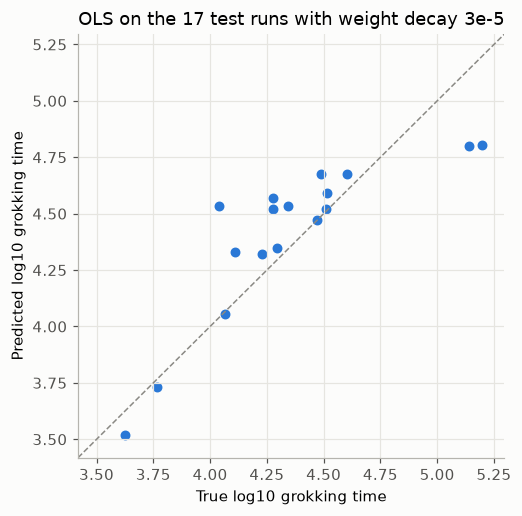

In [37]:
pred = preds_wd['OLS']
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test_wd, pred, s=30, color=WD_COLOUR)
lims = [min(y_test_wd.min(), pred.min()) - 0.1, max(y_test_wd.max(), pred.max()) + 0.1]
ax.plot(lims, lims, color=GREY, linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('True log10 grokking time')
ax.set_ylabel('Predicted log10 grokking time')
ax.set_title(f'OLS on the {len(y_test_wd)} test runs with {WD_LABEL}')
plt.show()

Most points lie close to the line. The two slowest runs, near 10^5.2 steps, are predicted too fast. A straight line pulls its predictions toward the middle, so the ends of the range are the hardest to get right.

### How much does the split matter?

The test set holds only 17 runs, so a small difference between the models on it could be luck. We repeat the whole process with 10 different splits of the runs with weight decay 3e-5. Each time we standardise on the new training set, fit all three models, and score them on the new test set.

`LinearRegression` from scikit-learn fits the same least-squares line as statsmodels. We use it in this loop because the loop needs only the predictions.

In [38]:
def split_scores(seed):
    order = np.random.default_rng(seed).permutation(len(data_wd))
    tr, te = data_wd.iloc[order[:n_train]], data_wd.iloc[order[n_train:]]
    X_tr, X_te = standardise(tr, tr), standardise(te, tr)
    models = {
        'OLS': LinearRegression(),
        'L1 (lasso)': LassoCV(cv=5),
        'L2 (ridge)': RidgeCV(alphas=np.logspace(-3, 3, 61), cv=5),
    }
    return {name: r2_score(te['log_t'], m.fit(X_tr, tr['log_t']).predict(X_te))
            for name, m in models.items()}

split_r2_wd = pd.DataFrame({seed: split_scores(seed) for seed in range(10)}).T
split_r2_wd.round(3)

,OLS,L1 (lasso),L2 (ridge)
0,0.690,0.689,0.691
1,0.778,0.778,0.777
2,0.776,0.775,0.772
3,0.430,0.458,0.487
4,0.590,0.590,0.572
5,0.732,0.725,0.734
6,0.800,0.800,0.803
7,0.708,0.706,0.708
8,0.793,0.786,0.788
9,0.711,0.721,0.728


In [39]:
split_r2_wd.describe().round(3)

,OLS,L1 (lasso),L2 (ridge)
count,10.000,10.000,10.000
mean,0.701,0.703,0.706
std,0.114,0.106,0.102
min,0.430,0.458,0.487
25%,0.694,0.693,0.695
50%,0.722,0.723,0.731
75%,0.777,0.777,0.776
max,0.800,0.800,0.803


**What the splits show.**

- The three models have a mean R squared of 0.70, 0.70 and 0.71 over the 10 splits. This difference is much smaller than the change from one split to the next, which has a standard deviation of about 0.1.
- The penalties help most on the worst split, seed 3. There the R squared rises from 0.43 with least squares to 0.46 with L1 and 0.49 with L2. On the other nine splits the three models agree to within 0.02.
- So the penalties add little to the score here. With only three inputs and 64 training runs, least squares has few coefficients to fit and little room to learn noise. Penalties matter more when a model has many inputs compared with the number of runs. What they add here is a second view of the inputs: the lasso drops `R_t`, which agrees with its p-value of 0.66 in Part 6.

## Part 8. Predict whether a run groks, with logistic regression

**Runs in this part.** All 90 runs with weight decay 3e-5 on the left, and all 90 runs without weight decay on the right. This part brings back the censored runs and the runs that never memorised.

Parts 3 to 7 used only the runs that grokked and asked how long they took. Here we ask an earlier question. From the kernel at step 2,000, can we tell whether a run will grok within the budget at all? The answer is yes or no, so a model for it is a classifier. We score a classifier by its **accuracy**, the share of runs it gets right.

Logistic regression is the classifier version of the straight line in Part 6. It computes the same kind of score from the inputs:

`score = intercept + b_A * A_t + b_S * S_t + b_R * R_t`

It then turns the score into a probability of grokking between 0 and 1 with the logistic function, `p = 1 / (1 + e^(-score))`. A score of 0 gives a probability of 0.5. The model predicts that a run groks when its probability is above 0.5.

Step 2,000 is still a safe time to read the inputs. Part 5 found that no grokked run generalises before step 4,000, and the other runs never generalise at all.

`with_label` takes all 90 runs of one weight decay level and joins the kernel at step 2,000 to them, from `step2000` in Part 5. It adds the target `grokked`, which is 1 if the run grokked and 0 if it did not. It also adds `log2_width`, the log, base 2, of the width, which a later step uses. The table counts the outcomes in each group.

In [40]:
def with_label(level_runs):
    data = level_runs[['run_id', 'alpha', 'width', 'outcome']].merge(step2000, on='run_id')
    data['grokked'] = (data['outcome'] == 'grokked').astype(int)
    data['log2_width'] = np.log2(data['width'])
    return data

labelled_wd = with_label(runs[np.isclose(runs['eta_kappa'], WD)])
labelled_no_wd = with_label(runs[runs['eta_kappa'] == 0])
groups[WD_LABEL]['labelled'] = labelled_wd
groups[NO_WD_LABEL]['labelled'] = labelled_no_wd
pd.DataFrame({label: group['labelled']['outcome'].value_counts()
              for label, group in groups.items()}).reindex(outcomes).fillna(0).astype(int)

,weight decay 3e-5,no weight decay
outcome,,
grokked,81,19
censored,8,68
never memorised,1,3


With weight decay 3e-5, 81 runs grokked and 9 did not: 8 were censored and 1 never memorised. Without weight decay, 19 runs grokked and 71 did not: 68 were censored and 3 never memorised. The target puts censored runs and runs that never memorised in the same class, the runs that did not grok.

### A baseline to beat

The two classes are uneven. A model that ignores the inputs and always guesses the larger class is already right on most runs. Its accuracy is the share of the larger class, and any real model has to beat it.

In [41]:
baseline_acc = pd.Series({
    label: max(group['labelled']['grokked'].mean(), 1 - group['labelled']['grokked'].mean())
    for label, group in groups.items()
}, name='always guess the larger class')
baseline_acc.round(3)

weight decay 3e-5    0.900
no weight decay      0.789
Name: always guess the larger class, dtype: float64

With weight decay, always guessing "grokked" is right on 90 percent of the runs. Without weight decay, always guessing "did not grok" is right on 79 percent. So in the left group an accuracy of 0.90 is no better than guessing. This is why we also count the runs that a model gets right within each class.

### Look first

Each input at step 2,000 for each outcome. Each row of panels is one input, and each column is one group, as in Part 5. The panels in a row share their vertical axis. Coloured dots are runs that grokked, and grey dots are runs that did not.

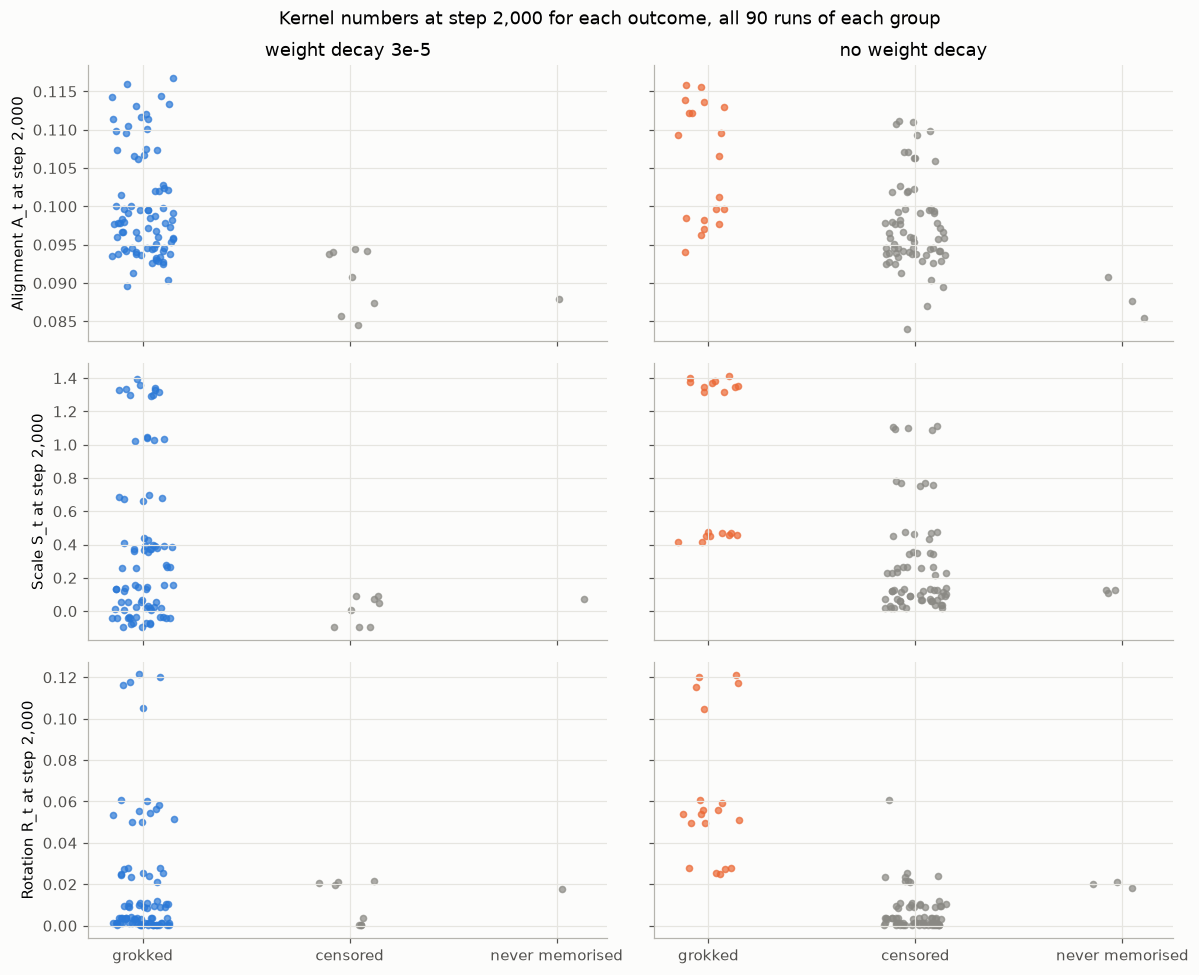

In [42]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True, sharey='row')
for col_axes, (label, group) in zip(axes.T, groups.items()):
    data = group['labelled']
    for ax, (col, name) in zip(col_axes, panels):
        for i, outcome in enumerate(outcomes):
            values = data.loc[data['outcome'] == outcome, col]
            colour = group['colour'] if outcome == 'grokked' else GREY
            ax.scatter(i + jitter.uniform(-0.15, 0.15, len(values)), values, s=16,
                       color=colour, alpha=0.7)
    col_axes[0].set_title(label)
    col_axes[-1].set_xticks(range(len(outcomes)), outcomes)
for ax, (col, name) in zip(axes[:, 0], panels):
    ax.set_ylabel(f'{name} at step 2,000')
fig.suptitle('Kernel numbers at step 2,000 for each outcome, all 90 runs of each group')
plt.tight_layout()
plt.show()

**What the plot shows.**

- With weight decay, the 9 runs that did not grok all sit at the low end: `A_t` below 0.095, `S_t` below 0.09 and `R_t` below 0.022. Many grokked runs sit there too, so no input splits the two classes on its own.
- Without weight decay, `R_t` splits the classes best. The lowest grokked run has an `R_t` of 0.025, and 69 of the 71 other runs lie below it. The grokked runs at `alpha` 1 and width 100 sit just above that line.
- Without weight decay, `S_t` splits the classes less well. The grokked runs sit in two bands, near 1.35 and near 0.45, and runs that did not grok spread from about 0 to 1.1.

### Fit the model

`logistic_model` builds the model in two steps joined by `make_pipeline`. `StandardScaler` rescales each input to mean 0 and standard deviation 1, the same job that `standardise` did in Parts 6 and 7. `LogisticRegression` then fits the model. Joining the two steps matters for the cross-validation below, because each fold is then rescaled with its own training runs only.

scikit-learn adds a light L2 penalty to logistic regression by default. This is the ridge penalty of Part 7. It keeps the coefficients finite when the two classes can be split almost perfectly, which happens in small groups like these.

We fit one model on all 90 runs of each group and print the three coefficients. A positive coefficient means that a larger value of that input makes grokking more likely. Because the inputs are standardised, the sizes can be compared within a group.

In [43]:
def logistic_model():
    return make_pipeline(StandardScaler(), LogisticRegression())

for group in groups.values():
    group['logistic'] = logistic_model().fit(group['labelled'][inputs], group['labelled']['grokked'])

pd.DataFrame({label: group['logistic'][-1].coef_[0] for label, group in groups.items()},
             index=list(names.values())).round(2)

,weight decay 3e-5,no weight decay
A_t,2.05,0.17
S_t,0.72,0.27
R_t,-0.23,2.46


With weight decay, `A_t` has the largest coefficient, 2.05. Runs whose kernel is better aligned at step 2,000 are more likely to grok. Without weight decay, `R_t` has the largest coefficient, 2.46, and `A_t` and `S_t` are near 0. This matches the plot above, where `R_t` split the classes best in that group.

In Parts 6 and 7, `R_t` added little to the grokking time of the runs that grokked. Here, without weight decay, it is the input that the model leans on to tell the grokked runs from the rest. The inputs are correlated, so another fit could share the weight between them differently.

### Accuracy on runs the model has not seen

A model always looks better on the runs it learned from. Part 7 kept 20 percent of the runs aside as a test set. Here that would be 18 runs, and in the group with weight decay only 2 of them would be runs that did not grok. So we use 5-fold cross-validation, as `LassoCV` did inside Part 7. We split the 90 runs into 5 parts, fit on 4 parts and predict the fifth, once for each part. Every run then gets one prediction from a model that did not see it.

`StratifiedKFold` keeps the share of grokked runs about the same in every part, so each part holds runs of both classes. `cross_val_predict` runs the whole loop and returns the predictions. The random seed makes the parts the same every time the notebook runs.

In [44]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
for group in groups.values():
    group['cv_pred'] = cross_val_predict(logistic_model(), group['labelled'][inputs],
                                         group['labelled']['grokked'], cv=folds)

We score the predictions in three ways. Accuracy is the share of all runs predicted right. The other two columns count the runs predicted right within each class, which shows whether the model does more than guess the larger class.

In [45]:
def class_scores(y, pred):
    return {
        'accuracy': round(accuracy_score(y, pred), 3),
        'grokked runs right': f"{((pred == 1) & (y == 1)).sum()} of {(y == 1).sum()}",
        'other runs right': f"{((pred == 0) & (y == 0)).sum()} of {(y == 0).sum()}",
    }

scores_logistic = pd.DataFrame.from_dict({
    label: class_scores(group['labelled']['grokked'].to_numpy(), group['cv_pred'])
    for label, group in groups.items()
}, orient='index')
scores_logistic.insert(1, 'baseline accuracy', baseline_acc.round(3))
scores_logistic

,accuracy,baseline accuracy,grokked runs right,other runs right
weight decay 3e-5,0.922,0.900,81 of 81,2 of 9
no weight decay,0.933,0.789,14 of 19,70 of 71


The same predictions as a confusion matrix for each group. Each row is the true outcome and each column is the predicted one. The number in a cell counts runs. The two cells on the diagonal hold the runs predicted right. The shade shows the share of the row, so a dark diagonal cell means the model gets most runs of that class right, however small the class is.

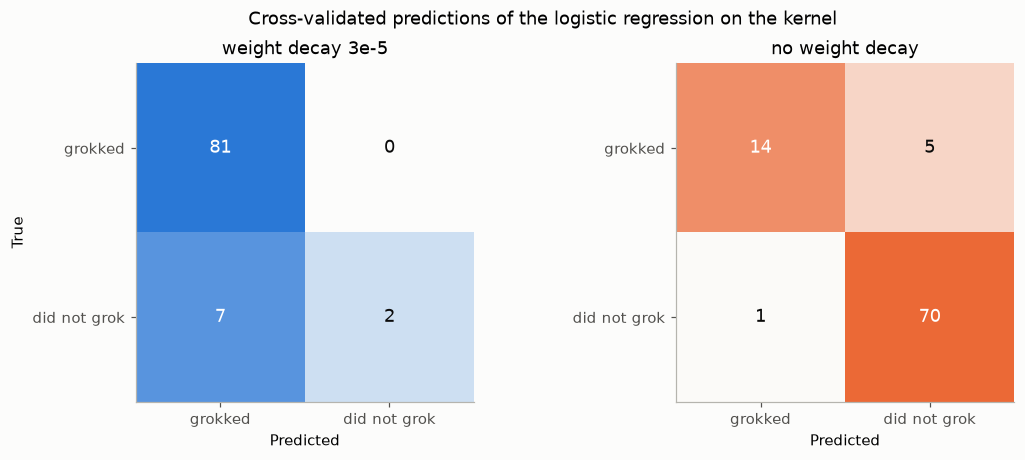

In [46]:
classes = [1, 0]
class_names = ['grokked', 'did not grok']

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout='constrained')
for ax, (label, group) in zip(axes, groups.items()):
    matrix = confusion_matrix(group['labelled']['grokked'], group['cv_pred'], labels=classes)
    shares = matrix / matrix.sum(axis=1, keepdims=True)
    ramp = LinearSegmentedColormap.from_list(label, [SURFACE, group['colour']])
    ax.imshow(shares, cmap=ramp, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, matrix[i, j], ha='center', va='center', fontsize=12,
                    color='white' if shares[i, j] > 0.6 else INK)
    ax.set_xticks([0, 1], class_names)
    ax.set_yticks([0, 1], class_names)
    ax.set_xlabel('Predicted')
    ax.set_title(label)
    ax.grid(False)
axes[0].set_ylabel('True')
fig.suptitle('Cross-validated predictions of the logistic regression on the kernel', y=1.06)
plt.show()

**What the scores show.**

- With weight decay, the model gets 83 of the 90 runs right, an accuracy of 0.922 against the baseline of 0.900. It gets every grokked run right, but it finds only 2 of the 9 runs that did not grok. So it beats always guessing "grokked" by 2 runs.
- Without weight decay, the model gets 84 of the 90 runs right, an accuracy of 0.933 against the baseline of 0.789. It finds 14 of the 19 grokked runs and 70 of the 71 others. This is a clear gain over guessing.

To see which runs the model gets wrong, we list them for each group.

In [47]:
wrong = pd.concat({
    label: group['labelled'].loc[group['cv_pred'] != group['labelled']['grokked'],
                                 ['run_id', 'outcome'] + inputs].rename(columns=names)
    for label, group in groups.items()
})
wrong.round(3)

run_id          outcome    A_t    S_t  \
weight decay 3e-5 10    ntk_N50_a2_wd3e-05_s0         censored  0.087  0.050   
                  13    ntk_N50_a2_wd3e-05_s3  never memorised  0.088  0.072   
                  14    ntk_N50_a2_wd3e-05_s4         censored  0.091  0.088   
                  44   ntk_N200_a2_wd3e-05_s4         censored  0.094  0.007   
                  85  ntk_N1600_a2_wd3e-05_s0         censored  0.094 -0.095   
                  86  ntk_N1600_a2_wd3e-05_s1         censored  0.094 -0.096   
                  89  ntk_N1600_a2_wd3e-05_s4         censored  0.094 -0.095   
no weight decay   6         ntk_N50_a1_wd0_s1         censored  0.092  0.432   
                  20       ntk_N100_a1_wd0_s0          grokked  0.101  0.469   
                  21       ntk_N100_a1_wd0_s1          grokked  0.097  0.449   
                  22       ntk_N100_a1_wd0_s2          grokked  0.098  0.459   
                  23       ntk_N100_a1_wd0_s3          grokked  0.098  0.453   
                  24       ntk_N100_a1_wd0_s4          grokked  0.100  0.458   

                        R_t  
weight decay 3e-5 10  0.021  
                  13  0.018  
                  14  0.020  
                  44  0.004  
                  85  0.000  
                  86  0.000  
                  89  0.000  
no weight decay   6   0.061  
                  20  0.028  
                  21  0.026  
                  22  0.028  
                  23  0.025  
                  24  0.027

- With weight decay, all 7 wrong runs are at `alpha` 2. They did not grok, and the model said they would. Their kernel has barely moved by step 2,000, and the grokked runs at `alpha` 2 look the same then: their `S_t` lies between -0.10 and 0.07. The 2 runs the model did find are seeds 1 and 2 at `alpha` 2 and width 50.
- Without weight decay, 5 of the 6 wrong runs are the 5 seeds at `alpha` 1 and width 100, the setting of the run in Part 4. These runs grokked, and the model said they would not. Their `R_t` lies between 0.025 and 0.028, at the edge of the runs that did not grok. The sixth is a censored run at `alpha` 1 and width 50, whose `R_t` of 0.061 looks like that of a grokked run.

### Does the kernel add anything to the settings?

Part 3 showed that the settings alone decide most outcomes. So we fit a second logistic regression on the two settings alone, `alpha` and `log2_width`, and score it with the same folds. If it does as well as the kernel, then the kernel tells us little that the settings do not already tell us.

In [48]:
setting_inputs = ['alpha', 'log2_width']
for group in groups.values():
    group['cv_pred_settings'] = cross_val_predict(logistic_model(), group['labelled'][setting_inputs],
                                                  group['labelled']['grokked'], cv=folds)

pd.DataFrame.from_dict({
    (label, model): class_scores(group['labelled']['grokked'].to_numpy(), group[pred])
    for label, group in groups.items()
    for model, pred in [('kernel', 'cv_pred'), ('settings', 'cv_pred_settings')]
}, orient='index')

accuracy grokked runs right other runs right
weight decay 3e-5 kernel       0.922           81 of 81           2 of 9
                  settings     0.900           81 of 81           0 of 9
no weight decay   kernel       0.933           14 of 19         70 of 71
                  settings     0.933           14 of 19         70 of 71

- With weight decay, the settings model predicts that every run groks. Its accuracy of 0.900 equals the baseline. The kernel model finds 2 of the 9 runs that did not grok, so the kernel adds a little here.
- Without weight decay, the two models make exactly the same prediction for every run, with an accuracy of 0.933. So in this group the kernel at step 2,000 tells us nothing that `alpha` and width do not. This fits Part 3, where the settings alone decided which runs grokked.

### How much do the near twins help?

The 5 seeds of one setting are near twins. With random folds, a run's twins usually sit in the training part, so the model has already seen almost the same run. A harder test holds out whole settings. `StratifiedGroupKFold` puts all 5 seeds of a setting in the same fold, when we give it the setting of each run as its group. The model then has to predict settings it has never seen.

One set of folds can be lucky, so `cv_accuracy` runs each kind of fold with 10 different seeds. The table gives the mean, lowest and highest accuracy over the 10 seeds.

In [49]:
def cv_accuracy(data, cols, seed, by_setting):
    y = data['grokked']
    if by_setting:
        setting = data['alpha'].astype(str) + '_' + data['width'].astype(str)
        folds = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        pred = cross_val_predict(logistic_model(), data[cols], y, cv=folds, groups=setting)
    else:
        folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        pred = cross_val_predict(logistic_model(), data[cols], y, cv=folds)
    return accuracy_score(y, pred)

rows = {}
for label, group in groups.items():
    for model, cols in [('kernel', inputs), ('settings', setting_inputs)]:
        for kind, by_setting in [('random', False), ('by setting', True)]:
            accs = [cv_accuracy(group['labelled'], cols, seed, by_setting) for seed in range(10)]
            rows[(label, model, kind)] = {'mean': np.mean(accs), 'lowest': np.min(accs), 'highest': np.max(accs)}
twin_check = pd.DataFrame.from_dict(rows, orient='index')
twin_check.index.names = ['group', 'inputs', 'folds']
twin_check.round(3)

mean  lowest  highest
group             inputs   folds                             
weight decay 3e-5 kernel   random      0.924   0.922    0.933
                           by setting  0.900   0.900    0.900
                  settings random      0.900   0.900    0.900
                           by setting  0.880   0.811    0.900
no weight decay   kernel   random      0.929   0.889    0.933
                           by setting  0.880   0.822    0.922
                  settings random      0.933   0.933    0.933
                           by setting  0.894   0.822    0.933

**What the table shows.**

- With random folds, the scores match the ones above. Over 10 seeds the kernel model averages 0.924 with weight decay and 0.929 without it.
- With weight decay, holding out whole settings drops the kernel model to 0.900 on every seed, which is the baseline. So its gain of 2 runs came from near twins in the training part. The settings model falls to 0.880, below the baseline.
- Without weight decay, holding out whole settings drops the kernel model to 0.880 on average, with a range from 0.822 to 0.922 over the seeds. The settings model drops to 0.894. Both stay above the baseline of 0.789, though the gain is smaller than random folds suggest.

So with 90 runs in each group, we cannot show that the kernel at step 2,000 predicts whether a run groks beyond what `alpha` and width already tell us.

## Summary

### Parts 1 and 2: all 720 runs

- The sweep ran every mix of 3 values of `alpha`, 6 widths, 8 weight decay levels and 5 seeds. 336 runs grokked, 189 were censored and 195 never memorised.
- Weight decay sets the outcome. Without it most runs are censored. From 3e-4 upward many runs never memorise. At 3e-5, 81 of the 90 runs grok.
- Among the runs that grok, the median grokking time falls by a factor of about 20 from weight decay 1e-5 to 1e-3.

### Part 3: the two groups side by side

- With weight decay 3e-5, runs grok at every width. `alpha` sets most of the grokking time, and past width 100 wider networks grok more slowly.
- Without weight decay, only widths 50 and 100 at `alpha` 0.5 and 1 grok. On these four shared settings, the runs without weight decay take 1.2 to 2.9 times longer.

### Part 4: one run from each group

- The two runs stay close until they generalise, and weight decay shortens the grokking time by about 16 percent.
- After generalisation the two runs part. Without weight decay the kernel keeps growing and its alignment falls. With weight decay the kernel shrinks and its alignment keeps rising.

### Parts 5 and 6: the kernel at step 2,000

- In both groups, all three kernel numbers are lower in runs that grok later. `A_t` has the strongest link, with correlations of -0.88 with weight decay and -0.91 without it.
- `A_t` and `S_t` have a correlation of about 0.95 in both groups, so a straight line cannot separate their effects. `R_t` adds little once they are in the line.
- The line explains 80 percent of the spread in log time with weight decay and 84 percent without it. Without weight decay this rests on 19 runs from 4 settings.

### Part 7: prediction for weight decay 3e-5

- The line predicts held-out runs with an R squared of about 0.7. The score ranges from 0.43 to 0.80 across 10 random splits.
- An L1 or an L2 penalty changes the test score by less than 0.02 on nine of the ten splits.

### Part 8: will a run grok? Both groups

- Always guessing the larger class is right on 90 percent of the runs with weight decay and 79 percent without it. Every accuracy has to be read against these numbers.
- With weight decay, logistic regression on the kernel at step 2,000 reaches an accuracy of 0.92 and finds 2 of the 9 runs that did not grok. When whole settings are held out, it falls to the baseline of 0.90.
- Without weight decay, it reaches 0.93, and `R_t` is the input it leans on. A model on `alpha` and width alone makes the same predictions, so in this group the kernel adds nothing beyond the settings.

### Limits to keep in mind

- Parts 3 to 7 leave out the censored runs, which removes the slowest runs. This matters most without weight decay, where 68 of the 90 runs were censored.
- The 5 seeds of one setting often land on both sides of the split. The test runs then have near twins in the training set, which makes the test easier than predicting a new setting. The cross-validation inside `LassoCV` and `RidgeCV` has the same problem, so it may choose penalties that are too weak.
- For the same reason, the standard errors and p-values in the statsmodels summaries are too small.
- The kernel numbers at step 2,000 also differ by `alpha` and width. For the yes or no question, Part 8 found that `alpha` and width alone do about as well as the kernel. The same check has not been run for the grokking time in Parts 6 and 7. Fitting a line on `alpha` and width alone, and comparing its score with the lines there, would show how much the kernel adds.